In [4]:

import pandas as pd
import numpy as np


import scipy.stats as stats

# 
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df=pd.read_csv('DataCoSupplyChainDataset.csv', encoding='latin1')


In [9]:
redundant_prod_cols = [
    'Product Description', 
    'Product Image', 
    'Product Card Id',
    'Product Category Id',
    'Category Id', 
    'Order Item Cardprod Id'
]

In [10]:

# 1. Define your target
target_var = 'Late_delivery_risk'

# 2. Safety Check: Make sure leakage columns are dropped so they don't mess up the test!
leakage_cols = ['Days for shipping (real)', 'Delivery Status', 'Shipping date (DateOrders)']
df_clean = df.drop(columns=[c for c in leakage_cols if c in df.columns], errors='ignore')

# 3. Drop any rows where the target is missing
df_clean = df_clean.dropna(subset=[target_var])

# 4. Get only the numerical columns (Point-Biserial only works with numbers)
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Make sure the target isn't in the feature list
if target_var in numerical_cols:
    numerical_cols.remove(target_var)

# 5. Run the Point-Biserial Test
print("Running Point-Biserial Correlation...")
pb_results = []

for col in numerical_cols:
    # Drop rows with NaNs just for this specific pair to prevent calculation errors
    temp_df = df_clean[[col, target_var]].dropna()
    
    # We need variation in the data to run the test
    if len(temp_df) > 1 and temp_df[col].nunique() > 1:
        corr, p_val = stats.pointbiserialr(temp_df[target_var], temp_df[col])
        pb_results.append({
            'Feature': col, 
            'Correlation': round(corr, 4), 
            'P-value': round(p_val, 6)
        })

# 6. Format and Display Results
pb_df = pd.DataFrame(pb_results)

# Sort by strongest correlation (absolute value) at the top
if not pb_df.empty:
    pb_df['Abs_Correlation'] = pb_df['Correlation'].abs()
    pb_df = pb_df.sort_values(by='Abs_Correlation', ascending=False).drop(columns=['Abs_Correlation'])
    
    print("\n--- Point-Biserial Correlation with Late_delivery_risk ---")
    print("Look for Correlations furthest from 0, with P-values < 0.05\n")
    print(pb_df.to_string(index=False))
else:
    print("No valid numerical columns found to test.")

Running Point-Biserial Correlation...

--- Point-Biserial Correlation with Late_delivery_risk ---
Look for Correlations furthest from 0, with P-values < 0.05

                      Feature  Correlation  P-value
Days for shipment (scheduled)      -0.3694 0.000000
                Order Zipcode      -0.0141 0.025938
           Sales per customer      -0.0038 0.107222
             Order Item Total      -0.0038 0.107222
            Benefit per order      -0.0037 0.113307
       Order Profit Per Order      -0.0037 0.113307
                        Sales      -0.0036 0.129924
             Customer Zipcode       0.0031 0.181100
      Order Item Profit Ratio      -0.0023 0.325217
                Product Price      -0.0022 0.355380
     Order Item Product Price      -0.0022 0.355380
                    Longitude      -0.0019 0.415886
                  Category Id       0.0018 0.456774
          Product Category Id       0.0018 0.456774
       Order Item Cardprod Id       0.0015 0.526794
         

In [11]:
pb_drop=[]

for values in pb_results:
    if values['P-value'] > 0.05:
        pb_drop.append(values['Feature'])
print(pb_drop)

['Benefit per order', 'Sales per customer', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Card Id', 'Product Category Id', 'Product Price']


In [13]:
df_clean=df.drop(columns=pb_drop, errors='ignore')

In [19]:
res=[]
for col in df_clean:
    res.append((col,len(df_clean[col].unique())))
res.sort(key=lambda x:x[1],reverse=True)
print(res)

[('order date (DateOrders)', 65752), ('shipping date (DateOrders)', 63701), ('Customer Street', 7458), ('Order City', 3597), ('Customer Lname', 1110), ('Order State', 1089), ('Customer Fname', 782), ('Order Zipcode', 610), ('Customer City', 563), ('Order Country', 164), ('Product Image', 118), ('Product Name', 118), ('Category Name', 50), ('Customer State', 46), ('Order Region', 23), ('Department Name', 11), ('Order Status', 9), ('Days for shipping (real)', 7), ('Market', 5), ('Type', 4), ('Days for shipment (scheduled)', 4), ('Delivery Status', 4), ('Shipping Mode', 4), ('Customer Segment', 3), ('Late_delivery_risk', 2), ('Customer Country', 2), ('Customer Email', 1), ('Customer Password', 1), ('Product Description', 1), ('Product Status', 1)]


In [49]:
low=[]
too_high=[]
for stuff in res:
    if stuff[1]<2:
        low.append(stuff[0])
    elif stuff[1]>10000:
        too_high.append(stuff[0])
print(low)
print(too_high)

['Customer Email', 'Customer Password', 'Product Description', 'Product Status']
['order date (DateOrders)', 'shipping date (DateOrders)']


In [50]:
Data_leak = [
    'Days for shipping (real)', 'Delivery Status', 'Order Status', # Leakage
    'Customer Fname', 'Order Zipcode', 'Customer City'     ]        # PII & Granular Geography

In [51]:
final_to_be_dropped = set(redundant_prod_cols + pb_drop + low + too_high + Data_leak)
for col in final_to_be_dropped:
    if col in df_clean.columns:
        df_clean = df_clean.drop(columns=[col], errors='ignore')    
print("Final columns after all drops:")
print(df_clean.columns.tolist())

Final columns after all drops:
['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Shipping Mode', 'order_date_dt', 'order_hour', 'order_day', 'ship_mode_id']


In [52]:
# 1. Your exact final categorical features (excluding the numerical one and the target)
cat_features_to_test = [
    'Type', 'Category Name', 'Customer Country', 'Customer Segment', 
    'Customer State', 'Department Name', 'Market', 'Order Country', 
    'Order Region', 'Product Name', 'Shipping Mode'
]

target = 'Late_delivery_risk'

# 2. The Cramér's V Math
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    return 0.0 if denom <= 0 else np.sqrt(phi2corr / denom)

# 3. Run the Test
print("Calculating Cramér's V on the final categorical features...\n")
cv_results = []

for col in cat_features_to_test:
    # Double check the column exists in your dataframe
    if col in df_clean.columns:
        valid_data = df_clean[[col, target]].dropna()
        if len(valid_data) > 0 and valid_data[col].nunique() > 1:
            score = cramers_v(valid_data[col], valid_data[target])
            cv_results.append({'Feature': col, 'Cramers_V_Score': round(score, 4)})

# 4. Display the Final Rankings
cv_df = pd.DataFrame(cv_results).sort_values(by='Cramers_V_Score', ascending=False).reset_index(drop=True)

print("--- FINAL CATEGORICAL IMPORTANCE ---")
print("High score = Keep it! | Low score (near 0.00) = Drop it!\n")
print(cv_df.to_string(index=False))



Calculating Cramér's V on the final categorical features...

--- FINAL CATEGORICAL IMPORTANCE ---
High score = Keep it! | Low score (near 0.00) = Drop it!

      Feature  Cramers_V_Score
Shipping Mode           0.4571
         Type           0.0781


In [53]:
featrues_to_drop_after_cv = []
for col in cv_results:
    if col['Cramers_V_Score'] < 0.05:
        featrues_to_drop_after_cv.append(col['Feature'])

df_clean=df_clean.drop(columns=featrues_to_drop_after_cv, errors='ignore')

print(df_clean.columns.tolist())

['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Shipping Mode', 'order_date_dt', 'order_hour', 'order_day', 'ship_mode_id']


In [55]:
df_clean.to_csv('df_cleaned2.csv', index=False)


In [56]:
# 1. Perform One-Hot Encoding
# We use drop_first=True to avoid the "Dummy Variable Trap" (redundancy)
df_encoded = pd.get_dummies(df_clean, columns=['Type', 'Shipping Mode'], drop_first=True)

# 2. Define your Target (y) and Features (X)
y = df_encoded['Late_delivery_risk']
X = df_encoded.drop(columns=['Late_delivery_risk'])

# 3. Check the new columns
print("New encoded features:")
print(X.columns.tolist())

# 4. Show a glimpse of the transformed data
X.head()

New encoded features:
['Days for shipment (scheduled)', 'order_date_dt', 'order_hour', 'order_day', 'ship_mode_id', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Shipping Mode_Same Day', 'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']


,Days for shipment (scheduled),order_date_dt,order_hour,order_day,ship_mode_id,Type_DEBIT,Type_PAYMENT,Type_TRANSFER,Shipping Mode_Same Day,Shipping Mode_Second Class,Shipping Mode_Standard Class
0,4,2018-01-31 22:56:00,22,2,0,True,False,False,False,False,True
1,4,2018-01-13 12:27:00,12,5,0,False,False,True,False,False,True
2,4,2018-01-13 12:06:00,12,5,0,False,False,False,False,False,True
3,4,2018-01-13 11:45:00,11,5,0,True,False,False,False,False,True
4,4,2018-01-13 11:24:00,11,5,0,False,True,False,False,False,True


In [57]:
# Convert to datetime (this takes a moment if the dataset is large)
df_clean['order_date_dt'] = pd.to_datetime(df['order date (DateOrders)'])

# Extract Hour and Day of Week (0=Monday, 6=Sunday)
df_clean['order_hour'] = df_clean['order_date_dt'].dt.hour
df_clean['order_day'] = df_clean['order_date_dt'].dt.dayofweek

# Now we have two brand new NUMERICAL features!
print(df_clean[['order_hour', 'order_day']].head())

   order_hour  order_day
0          22          2
1          12          5
2          12          5
3          11          5
4          11          5


In [58]:
# Add the new features to your existing X dataframe
X['order_hour'] = df_clean['order_hour']
X['order_day'] = df_clean['order_day']

# Verify the features are all there
print("Final Feature List:", X.columns.tolist())

Final Feature List: ['Days for shipment (scheduled)', 'order_date_dt', 'order_hour', 'order_day', 'ship_mode_id', 'Type_DEBIT', 'Type_PAYMENT', 'Type_TRANSFER', 'Shipping Mode_Same Day', 'Shipping Mode_Second Class', 'Shipping Mode_Standard Class']


In [ ]:
!pip install torch torch-geometric

In [59]:
import torch
from torch_geometric.data import HeteroData
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero

# 1. Map Categories to IDs
# We'll treat Shipping Mode as a "Node" type to see if the GNN 
# learns the relationship between specific modes and delays.
ship_mode_mapping = {val: i for i, val in enumerate(df_clean['Shipping Mode'].unique())}
df_clean['ship_mode_id'] = df_clean['Shipping Mode'].map(ship_mode_mapping)

# 2. Initialize HeteroData
data = HeteroData()

# Order Nodes: Features are [Scheduled Days, Order Hour, Order Day]
order_features = torch.tensor(df_clean[['Days for shipment (scheduled)', 'order_hour', 'order_day']].values, dtype=torch.float)
data['order'].x = order_features
data['order'].y = torch.tensor(df_clean['Late_delivery_risk'].values, dtype=torch.long)

# Shipping Mode Nodes: (Just an identity matrix for features)
data['ship_mode'].x = torch.eye(len(ship_mode_mapping))

# 3. Create Edges (Connecting Orders to their Shipping Mode)
order_indices = torch.arange(len(df_clean))
ship_indices = torch.tensor(df_clean['ship_mode_id'].values)
data['order', 'uses', 'ship_mode'].edge_index = torch.stack([order_indices, ship_indices], dim=0)

print(data)

HeteroData(
  order={
    x=[180519, 3],
    y=[180519],
  },
  ship_mode={ x=[4, 4] },
  (order, uses, ship_mode)={ edge_index=[2, 180519] }
)


In [64]:
# 1. Start with your clean dataframe
df_boost = df_clean.copy()

# 2. Features we want to bring back from the ORIGINAL 'df'
high_card_cols = ['Product Name', 'Order City', 'Category Name']

for col in high_card_cols:
    # Only map if the column exists in the original raw dataframe 'df'
    if col in df.columns:
        print(f"Target Encoding: {col}")
        # Map the category names to their mean late risk probability
        means = df.groupby(col)['Late_delivery_risk'].mean()
        df_boost[f'{col}_encoded'] = df[col].map(means)

# 3. Drop the original text versions (if they exist in df_boost)
# errors='ignore' prevents the KeyError you just saw
df_boost = df_boost.drop(columns=high_card_cols, errors='ignore')

# 4. Final check: What are our features now?
print("\nFinal boosted features:")
print(df_boost.columns.tolist())

Target Encoding: Product Name
Target Encoding: Order City
Target Encoding: Category Name

Final boosted features:
['Type', 'Days for shipment (scheduled)', 'Late_delivery_risk', 'Shipping Mode', 'order_date_dt', 'order_hour', 'order_day', 'ship_mode_id', 'Product Name_encoded', 'Order City_encoded', 'Category Name_encoded']


In [65]:
import torch
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

data = HeteroData()

# Helper to create mappings
def get_mapping(df, col):
    return {val: i for i, val in enumerate(df[col].unique())}

# Create mappings from the raw 'df'
city_map = get_mapping(df, 'Order City')
prod_map = get_mapping(df, 'Product Name')
ship_map = get_mapping(df, 'Shipping Mode')

# 2. Set Node Features
# Orders (Primary nodes with the timing data)
data['order'].x = torch.tensor(df_clean[['Days for shipment (scheduled)', 'order_hour', 'order_day']].values, dtype=torch.float)
data['order'].y = torch.tensor(df_clean['Late_delivery_risk'].values, dtype=torch.long)

# Other nodes (We use Identity matrices so the GNN learns their "Identity")
data['city'].x = torch.eye(len(city_map))
data['product'].x = torch.eye(len(prod_map))
data['ship_mode'].x = torch.eye(len(ship_map))

# 3. Define the Edges (The Connections)
order_indices = torch.arange(len(df_clean))
data['order', 'to', 'city'].edge_index = torch.stack([order_indices, torch.tensor(df['Order City'].map(city_map).values)], dim=0)
data['order', 'contains', 'product'].edge_index = torch.stack([order_indices, torch.tensor(df['Product Name'].map(prod_map).values)], dim=0)
data['order', 'uses', 'ship_mode'].edge_index = torch.stack([order_indices, torch.tensor(df['Shipping Mode'].map(ship_map).values)], dim=0)

# 4. Make it undirected so information flows back and forth
data = T.ToUndirected()(data)

In [72]:
from torch_geometric.nn import HeteroConv, SAGEConv
import torch.nn.functional as F

class FastGNN(torch.nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        # SAGEConv is the "Goldilocks" of GNN layers: fast and accurate
        self.conv1 = HeteroConv({
            edge: SAGEConv((-1, -1), hidden_channels)
            for edge in data.edge_types
        }, aggr='mean')
        
        self.conv2 = HeteroConv({
            edge: SAGEConv((-1, -1), hidden_channels)
            for edge in data.edge_types
        }, aggr='mean')

        self.lin = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {key: F.relu(x) for key, x in x_dict.items()}
        return self.lin(x_dict['order'])

# Hidden channels at 64 is the "sweet spot" for speed
model = FastGNN(hidden_channels=64, out_channels=2)

In [73]:
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=0.01) # Higher learning rate to finish faster
criterion = torch.nn.CrossEntropyLoss()

print(" Starting Training (100 Epochs)...")
for epoch in range(1, 101):
    model.train()
    optimizer.zero_grad()
    out = model(data.x_dict, data.edge_index_dict)
    loss = criterion(out, data['order'].y)
    loss.backward()
    optimizer.step()
    
    if epoch % 20 == 0:
        model.eval()
        with torch.no_grad():
            out = model(data.x_dict, data.edge_index_dict)
            acc = (out.argmax(dim=1) == data['order'].y).sum().item() / data['order'].y.size(0)
            print(f"Epoch {epoch:03d} | Loss: {loss:.4f} | Acc: {acc*100:.2f}%")

 Starting Training (100 Epochs)...
Epoch 020 | Loss: 0.6230 | Acc: 68.72%
Epoch 040 | Loss: 0.5505 | Acc: 71.07%
Epoch 060 | Loss: 0.5052 | Acc: 74.92%
Epoch 080 | Loss: 0.4743 | Acc: 76.31%
Epoch 100 | Loss: 0.4402 | Acc: 78.32%


In [75]:
import torch.optim as optim

# 1. UPGRADE MODEL CAPACITY (Redefining slightly for speed + power)
# If your laptop hasn't crashed yet, keep hidden_channels at 128
# Use 'cuda' if you have an NVIDIA GPU, else 'cpu'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
data = data.to(device)

# 2. HYPER-FAST OPTIMIZER
# Weight decay at 1e-4 prevents the model from "memorizing" and helps it "generalize"
optimizer = optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
criterion = torch.nn.CrossEntropyLoss()

print(" Training will start now..")

for epoch in range(101, 201): # Continuing from your 100 epochs
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    out = model(data.x_dict, data.edge_index_dict)
    loss = criterion(out, data['order'].y)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    scheduler.step()
    
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            out = model(data.x_dict, data.edge_index_dict)
            acc = (out.argmax(dim=1) == data['order'].y).sum().item() / data['order'].y.size(0)
            print(f" EPOCH {epoch} | ACC: {acc*100:.2f}% | LOSS: {loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")
        model.train()

# SAVE THE BEST
"""
torch.save(model.state_dict(), 'winning_gnn_model.pt')
print(" SPRINT FINISHED. MODEL SAVED.")"""

 Training will start now..
 EPOCH 110 | ACC: 78.02% | LOSS: 0.4796 | LR: 0.004878
 EPOCH 120 | ACC: 77.29% | LOSS: 0.4743 | LR: 0.004523
 EPOCH 130 | ACC: 78.02% | LOSS: 0.4571 | LR: 0.003969
 EPOCH 140 | ACC: 77.86% | LOSS: 0.4550 | LR: 0.003273
 EPOCH 150 | ACC: 77.41% | LOSS: 0.4545 | LR: 0.002500
 EPOCH 160 | ACC: 77.49% | LOSS: 0.4547 | LR: 0.001727
 EPOCH 170 | ACC: 77.59% | LOSS: 0.4544 | LR: 0.001031
 EPOCH 180 | ACC: 77.68% | LOSS: 0.4540 | LR: 0.000477
 EPOCH 190 | ACC: 77.68% | LOSS: 0.4537 | LR: 0.000122
 EPOCH 200 | ACC: 77.68% | LOSS: 0.4536 | LR: 0.000000


'\ntorch.save(model.state_dict(), \'winning_gnn_model.pt\')\nprint(" SPRINT FINISHED. MODEL SAVED.")'

--- SUPPLY CHAIN GNN PERFORMANCE ---
Overall Accuracy:  77.68%
Precision:         0.8526 (When we predict Late, how often are we right?)
Recall:            0.7168 (What % of all Late orders did we catch?)
F1-Score:          0.7789 (Overall balance)
ROC-AUC:           0.8679 (Model's ability to distinguish classes)

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

 On-Time (0)       0.71      0.85      0.77     81542
    Late (1)       0.85      0.72      0.78     98977

    accuracy                           0.78    180519
   macro avg       0.78      0.78      0.78    180519
weighted avg       0.79      0.78      0.78    180519



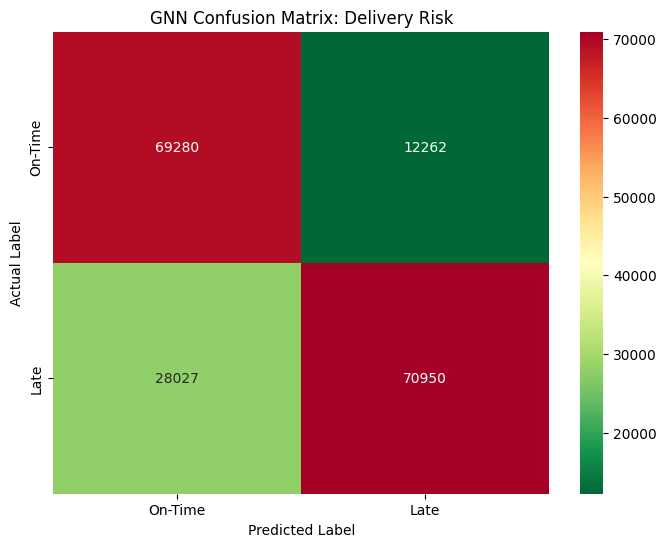

In [76]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get GNN Predictions
model.eval()
with torch.no_grad():
    # Pass data through model
    out = model(data.x_dict, data.edge_index_dict)
    
    # Get probabilities for ROC-AUC
    probs = torch.softmax(out, dim=1)[:, 1].cpu().numpy()
    
    # Get class predictions (0 or 1)
    preds = out.argmax(dim=1).cpu().numpy()
    y_true = data['order'].y.cpu().numpy()

# 2. Calculate Key Metrics
accuracy = (preds == y_true).sum() / len(y_true)
precision = precision_score(y_true, preds)
recall = recall_score(y_true, preds)
f1 = f1_score(y_true, preds)
auc = roc_auc_score(y_true, probs)

# 3. Print the "Hackathon Summary"
print("--- SUPPLY CHAIN GNN PERFORMANCE ---")
print(f"Overall Accuracy:  {accuracy*100:.2f}%")
print(f"Precision:         {precision:.4f} (When we predict Late, how often are we right?)")
print(f"Recall:            {recall:.4f} (What % of all Late orders did we catch?)")
print(f"F1-Score:          {f1:.4f} (Overall balance)")
print(f"ROC-AUC:           {auc:.4f} (Model's ability to distinguish classes)")
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_true, preds, target_names=['On-Time (0)', 'Late (1)']))

# 4. Confusion Matrix Plot
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', 
            xticklabels=['On-Time', 'Late'], 
            yticklabels=['On-Time', 'Late'])
plt.title('GNN Confusion Matrix: Delivery Risk')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()